In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import os

In [ ]:
def setZero(c,G,c0, G0=0):
    zero_ndx=min(range(len(c)), key=lambda i: abs(c[i]-c0)) #np.where(c==c0)[0][0]
    G_offset=[G[i]-G[zero_ndx]+G0 for i in range(len(G))]
    return G_offset

def interpDiffv1(r1,pmf1,r2,pmf2,rMax):
    from scipy.interpolate import interp1d

    # pmf1 is red, pmf2 is ref
    # Interpolated PMF
    f = interp1d(r1, pmf1, kind='linear')
    startIndex=next(x[0] for x in enumerate(r2) if x[1] > r1[0])
    endIndex=next(x[0] for x in enumerate(r2) if x[1] > rMax)
    r1Interp=r2[startIndex:endIndex]
    pmf1Interp=f(r1Interp)

    # Difference between PMFs
    diff=pmf2[startIndex:endIndex]-pmf1Interp

    # output
    return (r1Interp, pmf1Interp, diff)


def interpDiff(dr,rMax, r1,pmf1,r2,pmf2, sigma=1):
    from scipy.ndimage import gaussian_filter1d
    from scipy.interpolate import interp1d
    
    rInterp = np.arange(min(r1[0], r2[0]), rMax, dr)

    # Interpolated PMFs
    f1 = interp1d(r1, pmf1, kind='linear', bounds_error=False, fill_value="extrapolate")
    f2 = interp1d(r2, pmf2, kind='linear', bounds_error=False, fill_value="extrapolate")
        
    # Interpolated PMFs
    pmf1Interp = f1(rInterp)
    pmf2Interp = f2(rInterp)
    diff = pmf1Interp - pmf2Interp
    diff = gaussian_filter1d(diff, sigma)

    # Apply Gaussian smoothing to PMF
    diffData = np.column_stack((rInterp, diff))

    # output
    return (diffData, pmf1Interp, pmf2Interp)

def interpDiffGap(dr, r1Max, r2Min, r2Max, r1, pmf1, r2, pmf2, r3, pmf3, sigma=1):
    from scipy.ndimage import gaussian_filter1d
    from scipy.interpolate import interp1d

    # Create the interpolated r values for the range from r1[0] to r2Max
    rInterp = np.arange(min(r1[0], r2[0], r3[0]), r2Max, dr)

    # shift pmf2 and pmf3 to zero at r2Max
    pmf2 = setZero(r2, pmf2, r2Max)
    pmf3 = setZero(r3, pmf3, r2Max)
    # match pmf1 at r1Max to pmf2 at r2Min
    pmf2_r2Min = pmf2[min(range(len(r2)), key=lambda i: abs(r2[i]-r2Min))]
    pmf1 = setZero(r1, pmf1, r1Max, pmf2_r2Min)

    # Interpolate pmf1, pmf2, and pmf3
    interp_pmf1 = interp1d(r1, pmf1, kind='linear', bounds_error=False, fill_value="extrapolate")
    interp_pmf2 = interp1d(r2, pmf2, kind='linear', bounds_error=False, fill_value="extrapolate")
    interp_pmf3 = interp1d(r3, pmf3, kind='linear', bounds_error=False, fill_value="extrapolate")
    
    # Get the interpolated PMF values for rInterp
    pmf1Interp = interp_pmf1(rInterp)
    pmf2Interp = interp_pmf2(rInterp)
    pmf3Interp = interp_pmf3(rInterp)
    
    # Calculate the difference between pmfs
    diff13 = pmf1Interp - pmf3Interp
    diff23 = pmf2Interp - pmf3Interp
    
    # Create an array to store the difference values
    diff = np.full_like(rInterp, np.nan, dtype=float)
    diff[rInterp < r1Max] = diff13[rInterp < r1Max]
    diff[rInterp > r2Min] = diff23[rInterp > r2Min]

    # Create an interpolator function for the entire rInterp range
    # Exclude NaN values in the interpolation by masking
    valid_mask = ~np.isnan(diff)
    diffInterp = interp1d(rInterp[valid_mask], diff[valid_mask], kind='cubic', bounds_error=False, fill_value="extrapolate")

    # Interpolate the entire diff array
    diff = diffInterp(rInterp)
    diff_smooth = gaussian_filter1d(diff, sigma=sigma)
    
    # Return the column stack of rInterp and the smoothed difference
    return np.column_stack((rInterp, diff_smooth)), pmf1Interp, pmf2Interp, pmf3Interp, pmf2_r2Min

def writeDiff(r, diff, outFile, sysName):
    # Write to file
    header=[f'# {sysName}\n',
            f'# r0[nm] k[kCal/mol/nm^2]\n']
    outFileLines=header
    for i in range(len(r)):
        outFileLines.append(f'{r[i]:.4f} {diff[i]:.6f}\n')
        # outFileLines.append(f'{r[i]} {diff[i]}\n')
    with open(outFile, "w") as f: f.writelines(outFileLines)
    print(f'Written: {outFile}')

    # output

def coulomb(r, q1, q2, eps=78.5):
    e = 1.6e-19
    nm = 1e-9
    A = 6.022e23
    k_kCal = 1/(4 * np.pi * 8.854187817e-12) / 4.184e3
    const = k_kCal * e**2 / nm * A
    return const * q1 * q2 / (eps * r)

def loadPMF(file):
    if os.path.isfile(file):
        data = np.loadtxt(file)
        print(f'Loaded: {file}')
        return data
    else:
        print(f'NOT FOUND: {file}')  
        return file

    

Loaded: /Users/elha499/rc/gb-pmf-git/refData/daily/Na-Ac-BLYP-pmf.dat
Loaded: ace-na-t3p-pmf.dat
Loaded: ace-na-obc1-pmf.dat
Loaded: ace-na-t3p-obc1-pmf.dat
Loaded: ace-na-t3p-obc1-diff.dat
Loaded: ace-na-blypd-t3p-obc1-pmf.dat
Loaded: ace-na-blypd-t3p-obc1-diff.dat
Loaded: ace-na-blypd-t3p-pmf.dat
Loaded: ace-na-blypd-t3p-diff.dat


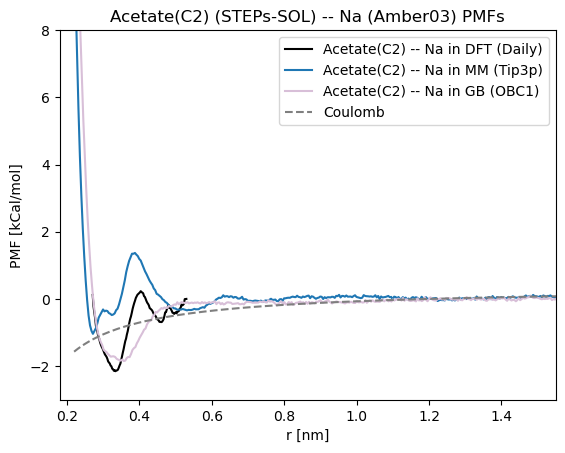

In [15]:
#### Setup #####################################################################
sysTitle = 'Acetate(C2) -- Na'
sysTitleFF = 'Acetate(C2) (STEPs-SOL) -- Na (Amber03)'
sysFileName = 'ace-na'
(q1, q2) = (-1, 1)

(gbModelFile, gbModelName) = ('obc1', 'GB (OBC1)')
(mmModelFile, mmModelName) = ('t3p', 'MM (Tip3p)')
(dftModelFile, dftModelName) = ('blypd', 'DFT (Daily)')

(gbxModelFile, gbxModelName) = (f'{mmModelFile}-{gbModelFile}', 'GB*')
(gbxxModelFile, gbxxModelName) = (f'{dftModelFile}-{mmModelFile}-{gbModelFile}', 'GB**')
(mmxModelFile, mmxModelName) = (f'{dftModelFile}-{mmModelFile}', 'MM*')

# Read in data
dftName = f'{sysTitle} in {dftModelName}'
dftPMF = loadPMF('/Users/elha499/rc/gb-pmf-git/refData/daily/Na-Ac-BLYP-pmf.dat')

mmName = f'{sysTitle} in {mmModelName}'
mmPMF = loadPMF(f'{sysFileName}-{mmModelFile}-pmf.dat')

gbName = f'{sysTitle} in {gbModelName}'
gbPMF = loadPMF(f'{sysFileName}-{gbModelFile}-pmf.dat')

gbxName = f'{sysTitle} in GB*'
gbxPMF = loadPMF(f'{sysFileName}-{gbxModelFile}-pmf.dat')
gbxDif = loadPMF(f'{sysFileName}-{gbxModelFile}-diff.dat')

gbxxName = f'{sysTitle} in GB**'
gbxxPMF = loadPMF(f'{sysFileName}-{gbxxModelFile}-pmf.dat')
gbxxDif = loadPMF(f'{sysFileName}-{gbxxModelFile}-diff.dat')

mmxName = f'{sysTitle} in MM*'
mmxPMF = loadPMF(f'{sysFileName}-{mmxModelFile}-pmf.dat')
mmxDif = loadPMF(f'{sysFileName}-{mmxModelFile}-diff.dat')

# Coulomb Reference
if type(dftPMF) != str:
    rMin = min(min(dftPMF[:,0]), min(mmPMF[:,0]), min(gbPMF[:,0]))
    rMax = max(max(dftPMF[:,0]), max(mmPMF[:,0]), max(gbPMF[:,0]))
else:
    rMin = min(min(mmPMF[:,0]), min(gbPMF[:,0]))
    rMax = max(max(mmPMF[:,0]), max(gbPMF[:,0]))
dr=0.01
rC = np.arange(rMin, rMax, dr)
coulV = [coulomb(r, q1, q2) for r in rC]
coulV = np.column_stack((rC, coulV))

# Plot All
for data, label, c, linestyle in [(dftPMF, dftName, 'k', '-'), 
                                  (mmPMF, mmName, 'tab:blue', '-'), 
                                  (gbPMF, gbName, 'thistle', '-'), 
                                  (coulV, 'Coulomb', 'tab:grey', '--')]:
    if type(data) != str:
        plt.plot(data[:,0], setZero(data[:,0], data[:,1], 1.2),
                 color=c, linestyle=linestyle, label=label)

plt.legend()
plt.xlabel('r [nm]')
plt.ylabel('PMF [kCal/mol]')
plt.title(f'{sysTitleFF} PMFs')
plt.ylim(-3, 8)
plt.xlim(0.18, 1.55)
plt.savefig(f'{sysFileName}-pmfs.svg')
plt.show()


Written: ace-na-blypd-pmfc.dat
Written: ace-na-t3p-pmfc.dat
Written: ace-na-obc1-pmfc.dat
Written: ace-na-t3p-obc1-pmfc.dat
Written: ace-na-blypd-t3p-obc1-pmfc.dat
Written: ace-na-blypd-t3p-pmfc.dat


Text(0, 0.5, 'PMF [kCal/mol]')

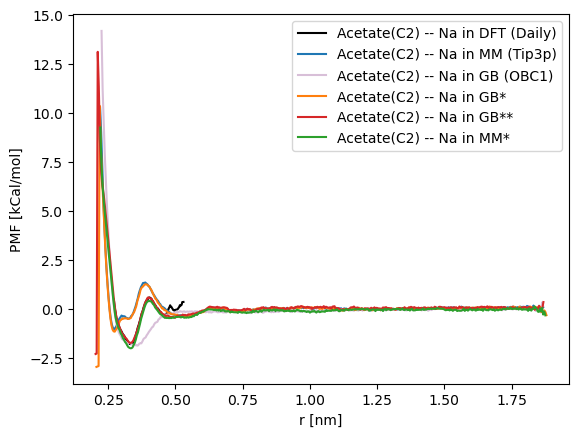

In [17]:
rMaxDFT=0.46
rMinMM=0.525
rMaxMM=1.2
dr = 0.005

i_rMinMM = next(x[0] for x in enumerate(mmPMF[:,0]) if x[1] > rMinMM)
i_rMaxMM = next(x[0] for x in enumerate(mmPMF[:,0]) if x[1] > rMaxMM)
if type(dftPMF) != str:
    i_rMaxDFT = next(x[0] for x in enumerate(dftPMF[:,0]) if x[1] > rMaxDFT)

# Adjust PMFs
if type(mmPMF) != str: mmPMF[:,1] = setZero(mmPMF[:,0], mmPMF[:,1], rMaxMM)
if type(gbPMF) != str: gbPMF[:,1] = setZero(gbPMF[:,0], gbPMF[:,1], rMaxMM)
if type(gbxPMF) != str: gbxPMF[:,1] = setZero(gbxPMF[:,0], gbxPMF[:,1], rMaxMM)
if type(gbxxPMF) != str: gbxxPMF[:,1] = setZero(gbxxPMF[:,0], gbxxPMF[:,1], rMaxMM)
if type(mmxPMF) != str: mmxPMF[:,1] = setZero(mmxPMF[:,0], mmxPMF[:,1], rMaxMM)

if type(mmPMF) != str: 
    refG= mmPMF[min(range(len(mmPMF)), key=lambda i: abs(mmPMF[i,0]-rMinMM)),1]
if type(dftPMF) != str: 
    dftPMF[:,1] = setZero(dftPMF[:,0], dftPMF[:,1], rMaxDFT, refG)

# plot y-adjusted PMFs
for data, label, model, c, linestyle in [(dftPMF, dftName, dftModelFile, 'k', '-'),
                                        (mmPMF, mmName, mmModelFile, 'tab:blue', '-'), 
                                        (gbPMF, gbName, gbModelFile, 'thistle', '-'), 
                                        (gbxPMF, gbxName, gbxModelFile, 'tab:orange', '-'), 
                                        (gbxxPMF, gbxxName, gbxxModelFile, 'tab:red', '-'),
                                        (mmxPMF, mmxName, mmxModelFile, 'tab:green', '-')]:
    if type(data) != str:
        plt.plot(data[:,0], data[:,1],
                 color=c, linestyle=linestyle, label=label)
        # save file
        writeDiff(data[:,0], data[:,1], f'{sysFileName}-{model}-pmfc.dat', label)

    else: print(f'NOT FOUND: {data}')

plt.legend()
plt.xlabel('r [nm]')
plt.ylabel('PMF [kCal/mol]')



Written: ace-na-t3p-obc1-diff.dat


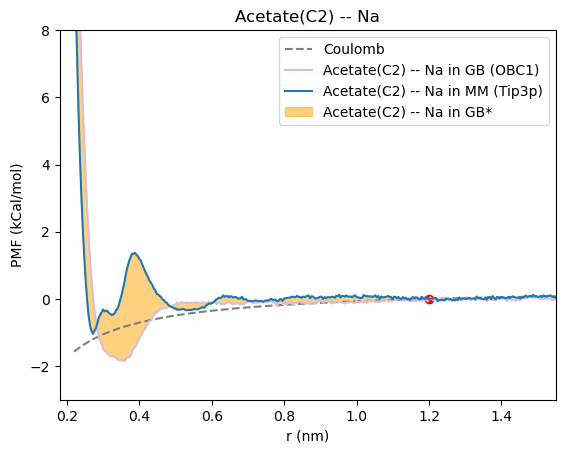

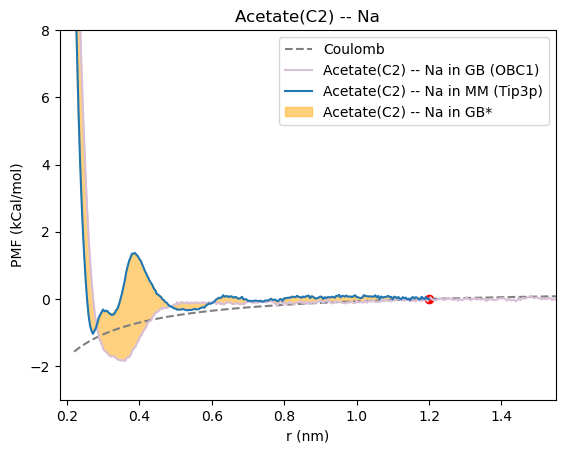

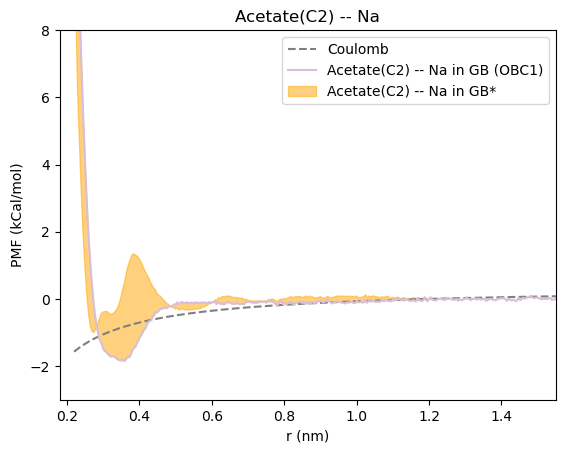

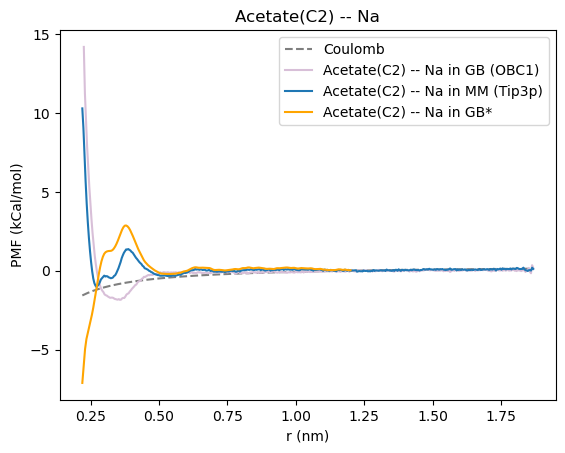

In [21]:
#### Generate GB* Diff ##########################################################
diffFilePrefix=f'{sysFileName}-{mmModelFile}-{gbModelFile}-diff'

# Interpolate PMF
gbxDif, mmInterp, gbInterp = interpDiff(dr, rMaxMM,
                                        mmPMF[:,0], setZero(mmPMF[:,0],mmPMF[:,1],rMaxMM),
                                        gbPMF[:,0], setZero(gbPMF[:,0],gbPMF[:,1],rMaxMM), sigma=1)
writeDiff(gbxDif[:,0], gbxDif[:,1], f'{diffFilePrefix}.dat', 
          f"{sysTitleFF} Difference Data: {mmModelName} - {gbModelName}")

# Plot fill
plt.plot(coulV[:,0], setZero(coulV[:,0],coulV[:,1],rMaxMM), 
         label='Coulomb', color='tab:grey', linestyle='--')
plt.plot(gbPMF[:,0], setZero(gbPMF[:,0],gbPMF[:,1],rMaxMM), 
         label=gbName, color='thistle')
plt.plot(mmPMF[:,0], setZero(mmPMF[:,0],mmPMF[:,1],rMaxMM), 
         label=mmName, color='tab:blue')
plt.fill_between(gbxDif[:,0], gbInterp, gbInterp+gbxDif[:,1],
                 color='orange', alpha=0.5, label=gbxName)
plt.scatter(rMaxMM, setZero(mmPMF[:,0],mmPMF[:,1],rMaxMM)[i_rMaxMM],
            color='r', marker='o')
plt.xlabel('r (nm)')
plt.ylabel('PMF (kCal/mol)')
plt.ylim(-3, 8)
plt.xlim(0.18, 1.55)
plt.legend()
plt.title(sysTitle)
plt.savefig(f'{diffFilePrefix}-fill.svg')
plt.show()

# Plot fill
plt.plot(coulV[:,0], setZero(coulV[:,0],coulV[:,1],rMaxMM), 
         label='Coulomb', color='tab:grey', linestyle='--')
plt.plot(gbPMF[:,0], setZero(gbPMF[:,0],gbPMF[:,1],rMaxMM), 
         label=gbName, color='thistle')
plt.plot(mmPMF[:i_rMaxMM,0], setZero(mmPMF[:,0],mmPMF[:,1],rMaxMM)[:i_rMaxMM], 
         label=mmName, color='tab:blue')
plt.fill_between(gbxDif[:,0], gbInterp, gbInterp+gbxDif[:,1],
                 color='orange', alpha=0.5, label=gbxName)
plt.scatter(rMaxMM, setZero(mmPMF[:,0],mmPMF[:,1],rMaxMM)[i_rMaxMM],
            color='r', marker='o')
plt.xlabel('r (nm)')
plt.ylabel('PMF (kCal/mol)')
plt.ylim(-3, 8)
plt.xlim(0.18, 1.55)
plt.legend()
plt.title(sysTitle)
plt.savefig(f'{diffFilePrefix}-fill2.svg')
plt.show()

# Plot fill
plt.plot(coulV[:,0], setZero(coulV[:,0],coulV[:,1],rMaxMM), 
         label='Coulomb', color='tab:grey', linestyle='--')
plt.plot(gbPMF[:,0], setZero(gbPMF[:,0],gbPMF[:,1],rMaxMM), 
         label=gbName, color='thistle')
plt.fill_between(gbxDif[:,0], gbInterp, gbInterp+gbxDif[:,1],
                 color='orange', alpha=0.5, label=gbxName)
plt.xlabel('r (nm)')
plt.ylabel('PMF (kCal/mol)')
plt.ylim(-3, 8)
plt.xlim(0.18, 1.55)
plt.legend()
plt.title(sysTitle)
plt.savefig(f'{diffFilePrefix}-fill3.svg')
plt.show()

# Plot
plt.plot(coulV[:,0], setZero(coulV[:,0],coulV[:,1],rMaxMM), 
         label='Coulomb',color='tab:grey', linestyle='--')
plt.plot(gbPMF[:,0], setZero(gbPMF[:,0],gbPMF[:,1],rMaxMM), 
         label=gbName, color='thistle')
plt.plot(mmPMF[:,0], setZero(mmPMF[:,0],mmPMF[:,1],rMaxMM), 
         label=mmName, color='tab:blue')
plt.plot(gbxDif[:,0], gbxDif[:,1],
         label=gbxName, color='orange')
plt.xlabel('r (nm)')
plt.ylabel('PMF (kCal/mol)')
plt.legend()
plt.title(sysTitle)
plt.savefig(f'{diffFilePrefix}.svg')
plt.show()

Written: ace-na-blypd-t3p-diff.dat


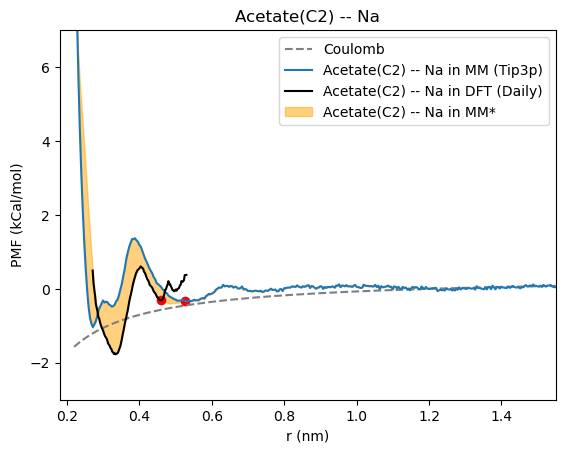

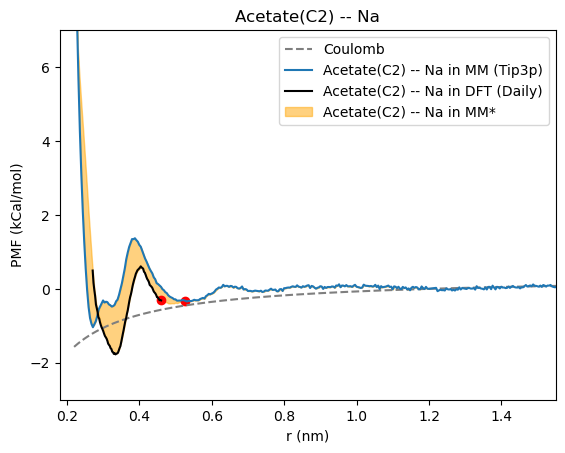

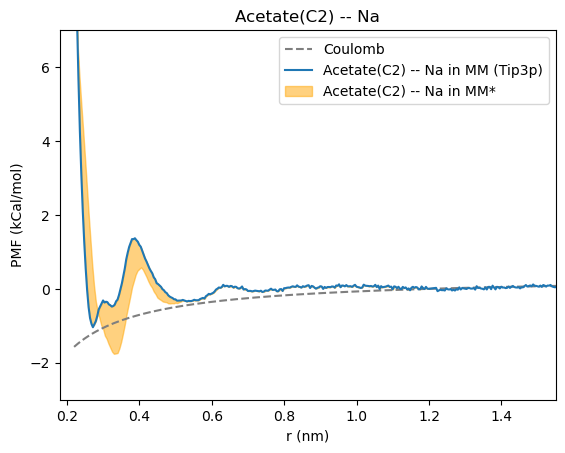

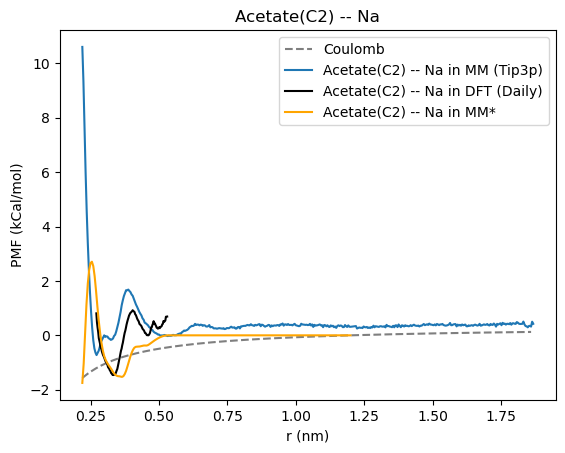

In [40]:
#### Generate MM* Diff ##########################################################
mmxDifPrefix=f'{sysFileName}-{dftModelFile}-{mmModelFile}-diff'

# Interpolate PMF
mmxDif, dftInterp, mmInterp, _, refG = interpDiffGap( dr, rMaxDFT, rMinMM, rMaxMM,
                                                    dftPMF[:,0], dftPMF[:,1], 
                                                    mmPMF[:,0], mmPMF[:,1],
                                                    mmPMF[:,0], mmPMF[:,1], sigma=1)
writeDiff(mmxDif[:,0],mmxDif[:,1], f'{mmxDifPrefix}.dat', 
          f"{sysTitleFF} Difference Data: {dftModelName} - {mmModelName}")

# Plot fill
plt.plot(coulV[:,0], setZero(coulV[:,0],coulV[:,1],rMaxMM), 
         label='Coulomb', color='tab:grey', linestyle='--')
plt.plot(mmPMF[:,0], setZero(mmPMF[:,0],mmPMF[:,1],rMaxMM),
            label=mmName, color='tab:blue')
plt.plot(dftPMF[:,0], setZero(dftPMF[:,0],dftPMF[:,1],rMaxDFT, refG),
            label=dftName, color='k')
plt.fill_between(mmxDif[:,0], mmInterp, mmInterp+mmxDif[:,1],
                 color='orange', alpha=0.5, label=mmxName)
plt.scatter(rMaxDFT, setZero(dftPMF[:,0],dftPMF[:,1],rMaxDFT, refG)[i_rMaxDFT],
            color='r', marker='o')
plt.scatter(rMinMM, setZero(mmPMF[:,0],mmPMF[:,1],rMaxMM)[i_rMinMM],
           color='r', marker='o')
plt.xlabel('r (nm)')
plt.ylabel('PMF (kCal/mol)')
plt.ylim(-3, 7)
plt.xlim(0.18, 1.55)
plt.legend()
plt.title(sysTitle)
plt.savefig(f'{mmxDifPrefix}-fill.svg')
plt.show()

# Plot fill
plt.plot(coulV[:,0], setZero(coulV[:,0],coulV[:,1],rMaxMM), 
         label='Coulomb', color='tab:grey', linestyle='--')
plt.plot(mmPMF[:,0], setZero(mmPMF[:,0],mmPMF[:,1],rMaxMM),
            label=mmName, color='tab:blue')
plt.plot(dftPMF[:i_rMaxDFT,0], setZero(dftPMF[:i_rMaxDFT,0],dftPMF[:i_rMaxDFT,1],rMaxDFT, refG),
            label=dftName, color='k')
plt.fill_between(mmxDif[:,0], mmInterp, mmInterp+mmxDif[:,1],
                 color='orange', alpha=0.5, label=mmxName)
plt.scatter(rMaxDFT, setZero(dftPMF[:,0],dftPMF[:,1],rMaxDFT, refG)[i_rMaxDFT],
            color='r', marker='o')
plt.scatter(rMinMM, setZero(mmPMF[:,0],mmPMF[:,1],rMaxMM)[i_rMinMM],
           color='r', marker='o')
plt.xlabel('r (nm)')
plt.ylabel('PMF (kCal/mol)')
plt.ylim(-3, 7)
plt.xlim(0.18, 1.55)
plt.legend()
plt.title(sysTitle)
plt.savefig(f'{mmxDifPrefix}-fill2.svg')
plt.show()

# Plot fill
plt.plot(coulV[:,0], setZero(coulV[:,0],coulV[:,1],rMaxMM), 
         label='Coulomb', color='tab:grey', linestyle='--')
plt.plot(mmPMF[:,0], setZero(mmPMF[:,0],mmPMF[:,1],rMaxMM),
            label=mmName, color='tab:blue')
plt.fill_between(mmxDif[:,0], mmInterp, mmInterp+mmxDif[:,1],
                 color='orange', alpha=0.5, label=mmxName)
plt.xlabel('r (nm)')
plt.ylabel('PMF (kCal/mol)')
plt.ylim(-3, 7)
plt.xlim(0.18, 1.55)
plt.legend()
plt.title(sysTitle)
plt.savefig(f'{mmxDifPrefix}-fill3.svg')
plt.show()

# Plot
plt.plot(coulV[:,0], setZero(coulV[:,0],coulV[:,1],rMaxMM), 
         label='Coulomb',color='tab:grey', linestyle='--')
plt.plot(mmPMF[:,0], setZero(mmPMF[:,0],mmPMF[:,1],rMinMM), 
         label=mmName, color='tab:blue')
plt.plot(dftPMF[:,0], setZero(dftPMF[:,0],dftPMF[:,1],rMaxDFT), 
         label=dftName, color='k')
plt.plot(mmxDif[:,0], mmxDif[:,1],
         label=mmxName, color='orange')
# plt.ylim(-4,6.5)
plt.xlabel('r (nm)')
plt.ylabel('PMF (kCal/mol)')
plt.legend()
plt.title(sysTitle)
plt.savefig(f'{mmxDifPrefix}.svg')
plt.show()

Written: ace-na-blypd-t3p-obc1-diff.dat


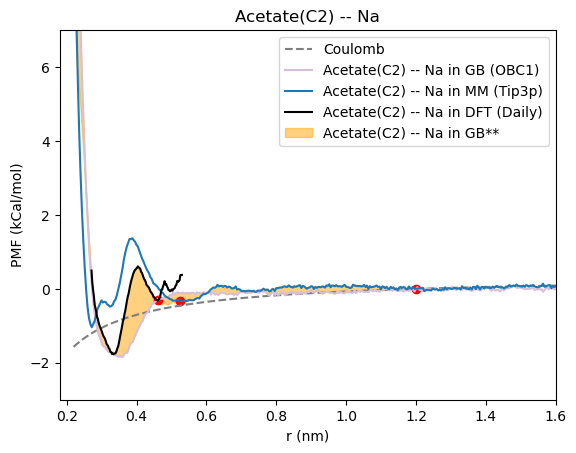

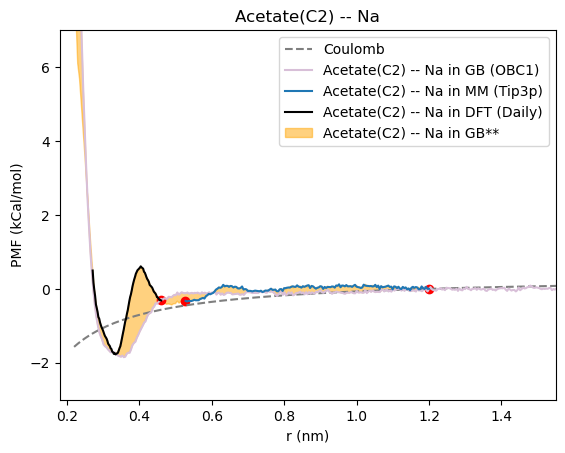

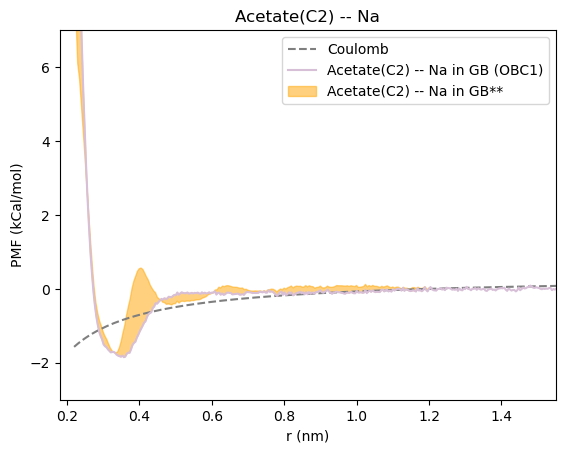

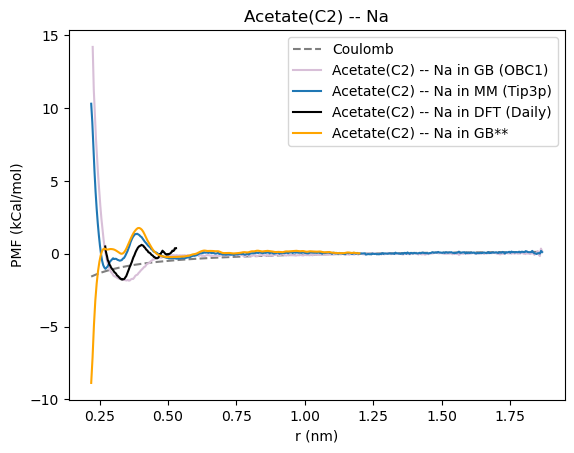

In [39]:
#### Generate GB** Diff ##########################################################
gbxxDifPrefix=f'{sysFileName}-{dftModelFile}-{mmModelFile}-{gbModelFile}-diff'

# Interpolate PMF
gbxxDif, dftInterp, mmInterp, gbInterp, refG = interpDiffGap( dr, rMaxDFT, rMinMM, rMaxMM,
                                                    dftPMF[:,0], dftPMF[:,1], 
                                                    mmPMF[:,0], mmPMF[:,1],
                                                    gbPMF[:,0], gbPMF[:,1], sigma=1)

i_rMaxMM = next(x[0] for x in enumerate(mmPMF[:,0]) if x[1] > rMaxMM)
i_rMinMM = next(x[0] for x in enumerate(mmPMF[:,0]) if x[1] > rMinMM)
i_rMaxDFT = next(x[0] for x in enumerate(dftPMF[:,0]) if x[1] > rMaxDFT)

writeDiff(gbxxDif[:,0], gbxxDif[:,1], f'{gbxxDifPrefix}.dat',
            f"{sysTitleFF} Difference Data: {dftModelName} - {gbModelName}")

# Plot fill
plt.plot(coulV[:,0], setZero(coulV[:,0],coulV[:,1],rMaxMM), 
         label='Coulomb', color='tab:grey', linestyle='--')
plt.plot(gbPMF[:,0], setZero(gbPMF[:,0],gbPMF[:,1],rMaxMM),
            label=gbName, color='thistle')
plt.plot(mmPMF[:,0], setZero(mmPMF[:,0],mmPMF[:,1],rMaxMM),
            label=mmName, color='tab:blue')
plt.plot(dftPMF[:,0], setZero(dftPMF[:,0],dftPMF[:,1],rMaxDFT, refG),
            label=dftName, color='k')
plt.fill_between(gbxxDif[:,0], gbInterp, gbInterp+gbxxDif[:,1],
                 color='orange', alpha=0.5, label=gbxxName)
plt.scatter(rMaxDFT, setZero(dftPMF[:,0],dftPMF[:,1],rMaxDFT, refG)[i_rMaxDFT],
            color='r', marker='o')
plt.scatter(rMinMM, setZero(mmPMF[:,0],mmPMF[:,1],rMaxMM)[i_rMinMM],
           color='r', marker='o')
plt.scatter(rMaxMM, setZero(mmPMF[:,0],mmPMF[:,1],rMaxMM)[i_rMaxMM],
           color='r', marker='o')
plt.xlabel('r (nm)')
plt.ylabel('PMF (kCal/mol)')
plt.ylim(-3, 7)
plt.xlim(0.18, 1.6)
plt.legend()
plt.title(sysTitle)
plt.savefig(f'{gbxxDifPrefix}-fill.svg')
plt.show()

# Plot fill 
plt.plot(coulV[:,0], setZero(coulV[:,0],coulV[:,1],rMaxMM), 
         label='Coulomb', color='tab:grey', linestyle='--')
plt.plot(gbPMF[:,0], setZero(gbPMF[:,0],gbPMF[:,1],rMaxMM),
            label=gbName, color='thistle')
plt.plot(mmPMF[i_rMinMM:i_rMaxMM,0], setZero(mmPMF[i_rMinMM:i_rMaxMM,0],mmPMF[i_rMinMM:i_rMaxMM,1],rMaxMM),
            label=mmName, color='tab:blue')
plt.plot(dftPMF[:i_rMaxDFT,0], setZero(dftPMF[:i_rMaxDFT,0],dftPMF[:i_rMaxDFT,1],rMaxDFT, refG),
            label=dftName, color='k')
plt.fill_between(gbxxDif[:,0], gbInterp, gbInterp+gbxxDif[:,1],
                 color='orange', alpha=0.5, label=gbxxName)
plt.scatter(rMaxDFT, setZero(dftPMF[:,0],dftPMF[:,1],rMaxDFT, refG)[i_rMaxDFT],
            color='r', marker='o')
plt.scatter(rMinMM, setZero(mmPMF[:,0],mmPMF[:,1],rMaxMM)[i_rMinMM],
           color='r', marker='o')
plt.scatter(rMaxMM, setZero(mmPMF[:,0],mmPMF[:,1],rMaxMM)[i_rMaxMM],
           color='r', marker='o')
plt.xlabel('r (nm)')
plt.ylabel('PMF (kCal/mol)')
plt.ylim(-3, 7)
plt.xlim(0.18, 1.55)
plt.legend()
plt.title(sysTitle)
plt.savefig(f'{gbxxDifPrefix}-fill2.svg')
plt.show()

# Plot fill 
plt.plot(coulV[:,0], setZero(coulV[:,0],coulV[:,1],rMaxMM), 
         label='Coulomb', color='tab:grey', linestyle='--')
plt.plot(gbPMF[:,0], setZero(gbPMF[:,0],gbPMF[:,1],rMaxMM),
            label=gbName, color='thistle')
plt.fill_between(gbxxDif[:,0], gbInterp, gbInterp+gbxxDif[:,1],
                 color='orange', alpha=0.5, label=gbxxName)

plt.xlabel('r (nm)')
plt.ylabel('PMF (kCal/mol)')
plt.ylim(-3, 7)
plt.xlim(0.18, 1.55)
plt.legend()
plt.title(sysTitle)
plt.savefig(f'{gbxxDifPrefix}-fill3.svg')
plt.show()

# Plot
plt.plot(coulV[:,0], setZero(coulV[:,0],coulV[:,1],rMaxMM), 
         label='Coulomb',color='tab:grey', linestyle='--')
plt.plot(gbPMF[:,0], setZero(gbPMF[:,0],gbPMF[:,1],rMaxMM),
            label=gbName, color='thistle')
plt.plot(mmPMF[:,0], setZero(mmPMF[:,0],mmPMF[:,1],rMaxMM),
            label=mmName, color='tab:blue')
plt.plot(dftPMF[:,0], setZero(dftPMF[:,0],dftPMF[:,1],rMaxDFT, refG),
            label=dftName, color='k')
plt.plot(gbxxDif[:,0], gbxxDif[:,1],
            label=gbxxName, color='orange')
plt.xlabel('r (nm)')
plt.ylabel('PMF (kCal/mol)')
plt.legend()
plt.title(sysTitle)
plt.savefig(f'{gbxxDifPrefix}.svg')
plt.show()